<a href="https://colab.research.google.com/github/tlrvna/food-ai-practice/blob/main/%EC%8B%9D%ED%92%88%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%9C%B5%ED%95%A9%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%EC%8B%A4%EC%8A%B5_%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_222217%EC%97%84%EC%88%98%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

wine_quality = fetch_ucirepo(id=186)

X_wine = wine_quality.data.features
y_wine = wine_quality.data.targets

df_wine = pd.concat([X_wine, y_wine], axis=1)

In [2]:
def convert_quality(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

df_wine["label"] = df_wine["quality"].apply(convert_quality)

In [3]:
print(df_wine["label"].value_counts())

label
medium    2836
low       2384
high      1277
Name: count, dtype: int64


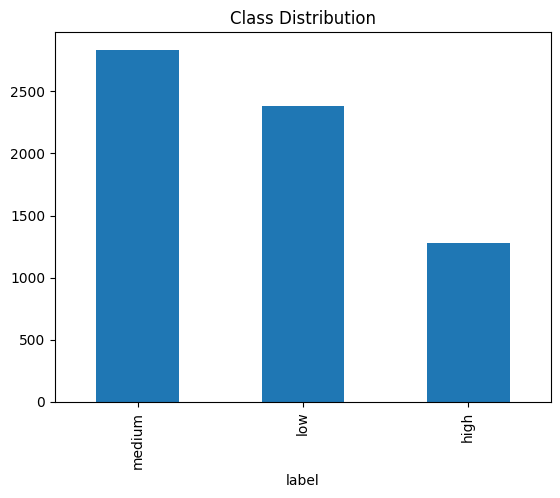

In [4]:
import matplotlib.pyplot as plt

df_wine["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

In [5]:
if "grade" in df_wine.columns:
    X = df_wine.drop(columns=["quality", "label", "grade"])
else:
    X = df_wine.drop(columns=["quality", "label"])

y = df_wine["label"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=1000,
        class_weight=None
    ))
])

baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred_base))
print(classification_report(y_test, pred_base))

Accuracy: 0.5846153846153846
              precision    recall  f1-score   support

        high       0.56      0.32      0.41       256
         low       0.67      0.62      0.65       477
      medium       0.54      0.67      0.59       567

    accuracy                           0.58      1300
   macro avg       0.59      0.54      0.55      1300
weighted avg       0.59      0.58      0.58      1300



In [9]:
trial1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=1000,
        class_weight="balanced"
    ))
])

trial1.fit(X_train, y_train)

pred_trial1 = trial1.predict(X_test)

print(classification_report(y_test, pred_trial1))

              precision    recall  f1-score   support

        high       0.41      0.70      0.52       256
         low       0.65      0.69      0.67       477
      medium       0.54      0.34      0.41       567

    accuracy                           0.54      1300
   macro avg       0.53      0.58      0.53      1300
weighted avg       0.55      0.54      0.53      1300



In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    baseline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

print(grid.best_params_)
print(classification_report(y_test, pred_best))

{'model__C': 1, 'model__class_weight': None}
              precision    recall  f1-score   support

        high       0.56      0.32      0.41       256
         low       0.67      0.62      0.65       477
      medium       0.54      0.67      0.59       567

    accuracy                           0.58      1300
   macro avg       0.59      0.54      0.55      1300
weighted avg       0.59      0.58      0.58      1300



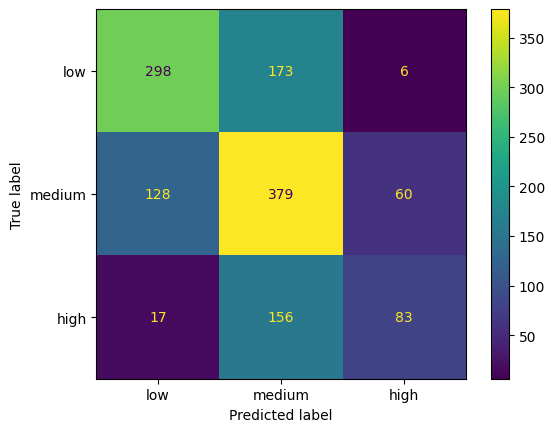

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    pred_best,
    labels=["low", "medium", "high"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["low", "medium", "high"]
)

disp.plot()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score

print("Baseline Accuracy:", accuracy_score(y_test, pred_base))
print("Trial1 Accuracy:", accuracy_score(y_test, pred_trial1))
print("Best Model Accuracy:", accuracy_score(y_test, pred_best))

Baseline Accuracy: 0.5846153846153846
Trial1 Accuracy: 0.5392307692307692
Best Model Accuracy: 0.5846153846153846


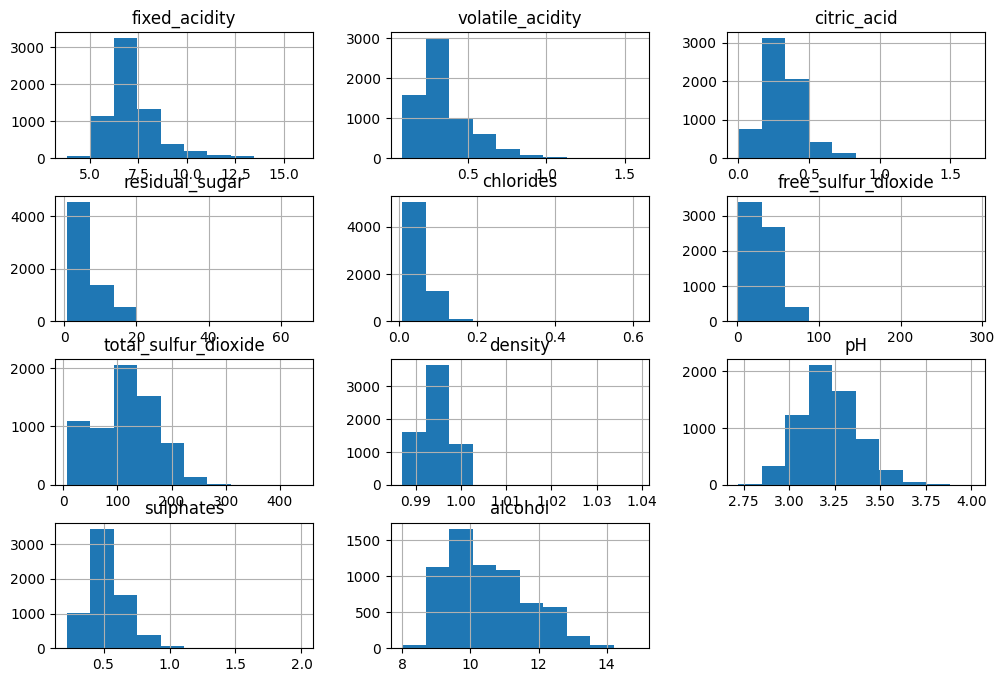

In [13]:
import matplotlib.pyplot as plt

X.hist(figsize=(12, 8))
plt.show()

In [14]:
print("Best Parameters:", grid.best_params_)
print(classification_report(y_test, pred_best))

Best Parameters: {'model__C': 1, 'model__class_weight': None}
              precision    recall  f1-score   support

        high       0.56      0.32      0.41       256
         low       0.67      0.62      0.65       477
      medium       0.54      0.67      0.59       567

    accuracy                           0.58      1300
   macro avg       0.59      0.54      0.55      1300
weighted avg       0.59      0.58      0.58      1300



In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score

result_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Balanced(class_weight)",
        "GridSearchCV(Final)"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_base),
        accuracy_score(y_test, pred_trial1),
        accuracy_score(y_test, pred_best)
    ]
})

result_df.to_csv("result_comparison.csv",
                 index=False,
                 encoding="utf-8-sig")

print(result_df)

                    Model  Accuracy
0                Baseline  0.584615
1  Balanced(class_weight)  0.539231
2     GridSearchCV(Final)  0.584615
